# Triadic Cell Notebook v46
## Local 4060 Resistance Harness

v45 proved the pipeline runs locally. v46 asks the useful question:

$$
\boxed{\text{does the triadic controller help when the base model is under pressure?}}
$$

Defaults:
- cached local model only: `LOCAL_FILES_ONLY = True`
- no hardcoded HF token
- built-in resistance dataset
- external JSONL support
- controller ablations: `full`, `no_base`, `shape_only`
- gated repair layer to prevent unnecessary controller damage

External JSONL format:

```json
{"id":"q1","prompt":"Question text","choices":["a","b","c","d"],"answer_idx":2,"band":"trap"}
```

In [1]:
# Optional installs if needed:
# %pip install -q torch transformers pandas matplotlib tqdm accelerate sentence-transformers

from __future__ import annotations
import os, json, math
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel

try:
    from sentence_transformers import SentenceTransformer
    HAVE_ST = True
except Exception:
    SentenceTransformer = None
    HAVE_ST = False

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

# -----------------------------
# CONFIG
# -----------------------------
DATA_JSONL = ""      # leave empty for built-in resistance set
MAX_SAMPLES = 64

HF_TOKEN = os.getenv("HF_TOKEN", "")
LOCAL_FILES_ONLY = True

MODEL_PROFILE = "qwen25_1p5b_instruct"

MODEL_PROFILES = {
    "qwen25_1p5b_instruct": {
        "MODEL_NAME": "Qwen/Qwen2.5-1.5B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 64,
    },
    "qwen25_3b_instruct": {
        "MODEL_NAME": "Qwen/Qwen2.5-3B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 48,
    },
    "qwen25_coder_1p5b": {
        "MODEL_NAME": "Qwen/Qwen2.5-Coder-1.5B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 64,
    },
    "qwen25_coder_3b": {
        "MODEL_NAME": "Qwen/Qwen2.5-Coder-3B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 48,
    },
}

profile = MODEL_PROFILES[MODEL_PROFILE]
MODEL_NAME = profile["MODEL_NAME"]
EMBED_MODEL_NAME = profile["EMBED_MODEL_NAME"]
MAX_SAMPLES = min(MAX_SAMPLES, profile["MAX_SAMPLES_CAP"])

USE_CHAT_TEMPLATE = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

OBS_DIM = 12
CYCLES = 6
EXHALE_STEPS = 3
STEP_SIZE = 0.42
DAMPING = 0.84
ANTI_SCALE = 0.35

BASE_MARGIN_KEEP = 0.85
BASE_MARGIN_ALLOW_OVERRIDE = 0.55
CTRL_MARGIN_OVERRIDE = 0.12

OUTPUT_DIR = f"v46_outputs_{MODEL_PROFILE}"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no cuda")
print("MODEL:", MODEL_NAME)
print("EMBED:", EMBED_MODEL_NAME)
print("LOCAL_FILES_ONLY:", LOCAL_FILES_ONLY)
print("DEVICE:", DEVICE, "DTYPE:", DTYPE)
print("OUTPUT_DIR:", OUTPUT_DIR)

torch: 2.11.0+cu126
cuda: True
gpu: NVIDIA GeForce RTX 4060
MODEL: Qwen/Qwen2.5-1.5B-Instruct
EMBED: sentence-transformers/all-MiniLM-L6-v2
LOCAL_FILES_ONLY: True
DEVICE: cuda DTYPE: torch.float16
OUTPUT_DIR: v46_outputs_qwen25_1p5b_instruct


In [2]:
# Built-in resistance set.
# Bands: easy, ambiguous, trap, logic, shape.
RESISTANCE_DATA = [
    {"id":"easy_1","band":"easy","prompt":"Which planet is known as the Red Planet?","choices":["Earth","Mars","Venus","Jupiter"],"answer_idx":1},
    {"id":"easy_2","band":"easy","prompt":"What gas do plants primarily absorb from the atmosphere?","choices":["Oxygen","Hydrogen","Carbon dioxide","Nitrogen"],"answer_idx":2},
    {"id":"easy_3","band":"easy","prompt":"What is the capital of Japan?","choices":["Beijing","Seoul","Tokyo","Kyoto"],"answer_idx":2},
    {"id":"easy_4","band":"easy","prompt":"Which number is prime?","choices":["21","35","37","49"],"answer_idx":2},

    {"id":"amb_1","band":"ambiguous","prompt":"Which term best means 'able to be understood in more than one way'?","choices":["accurate","ambiguous","literal","obsolete"],"answer_idx":1},
    {"id":"amb_2","band":"ambiguous","prompt":"A system returns to stable behavior after a disturbance. Which term fits best?","choices":["fragile","resilient","random","orthogonal"],"answer_idx":1},
    {"id":"amb_3","band":"ambiguous","prompt":"Which choice best describes a boundary that controls what can pass through it?","choices":["interface","archive","constant","duplicate"],"answer_idx":0},
    {"id":"amb_4","band":"ambiguous","prompt":"Which word best describes hiding implementation details behind a simple public surface?","choices":["encapsulation","translation","recursion","pagination"],"answer_idx":0},
    {"id":"amb_5","band":"ambiguous","prompt":"Which term means a stable repeating behavior that a dynamic system tends toward?","choices":["attractor","exception","literal","syntax"],"answer_idx":0},
    {"id":"amb_6","band":"ambiguous","prompt":"Which operation most directly combines parts under a constraint?","choices":["coupling","deletion","naming","printing"],"answer_idx":0},

    {"id":"trap_1","band":"trap","prompt":"A database index helps find rows quickly. Which item is most like an index?","choices":["a printed book cover","a map from key to location","a random password","a paint color"],"answer_idx":1},
    {"id":"trap_2","band":"trap","prompt":"In code, a function named getUser() should most directly do what?","choices":["delete all users","return a user or user data","compile the database","change the server clock"],"answer_idx":1},
    {"id":"trap_3","band":"trap","prompt":"A cache is useful mainly because it:","choices":["stores recent results for faster reuse","guarantees truth forever","removes all memory use","encrypts every variable"],"answer_idx":0},
    {"id":"trap_4","band":"trap","prompt":"If a pipe adapter must connect two different diameters, the important property is:","choices":["matching the paint","fitting both ends","being the heaviest piece","having the longest name"],"answer_idx":1},
    {"id":"trap_5","band":"trap","prompt":"If a prompt asks for only the final letter A-D, the safest output format is:","choices":["a paragraph explaining all choices","the single selected letter","a JSON object with citations","a poem"],"answer_idx":1},
    {"id":"trap_6","band":"trap","prompt":"A screwdriver works because its tip shape matches the screw slot. What is the key relation?","choices":["semantic similarity","geometric fit","calendar order","file size"],"answer_idx":1},

    {"id":"logic_1","band":"logic","prompt":"All bloops are razzies. Some razzies are lazzies. Which must be true?","choices":["All bloops are lazzies","Some lazzies are bloops","All bloops are razzies","No razzies are bloops"],"answer_idx":2},
    {"id":"logic_2","band":"logic","prompt":"If the switch is off, the lamp is dark. The lamp is not dark. What follows?","choices":["The switch is off","The switch is not off","The lamp is broken","Nothing follows"],"answer_idx":1},
    {"id":"logic_3","band":"logic","prompt":"A box contains red and blue balls. You remove all red balls. What can remain?","choices":["only red balls","blue balls or nothing","red and blue balls","a guaranteed blue ball"],"answer_idx":1},
    {"id":"logic_4","band":"logic","prompt":"You need a tool that applies torque to a hex bolt. Which is the best fit?","choices":["paintbrush","wrench","thermometer","bookmark"],"answer_idx":1},
    {"id":"logic_5","band":"logic","prompt":"If every valid answer must satisfy constraints A and B, which candidate is valid?","choices":["satisfies A only","satisfies B only","satisfies A and B","satisfies neither"],"answer_idx":2},
    {"id":"logic_6","band":"logic","prompt":"A thing is useful here only if it fits the socket and can carry current. Which candidate is best?","choices":["decorative plug-shaped toy","electrical plug with matching prongs","loose wire with no connector","wooden dowel"],"answer_idx":1},

    {"id":"shape_1","band":"shape","prompt":"A loose round coupler needs temporary compression around its outside. Which available item most directly supplies that shape?","choices":["tight O-rings","flat sheet of paper","loose string lying straight","a marker cap"],"answer_idx":0},
    {"id":"shape_2","band":"shape","prompt":"A tent must become portable without destroying shelter function. What is the central operation?","choices":["folding into a smaller carried form","painting it darker","renaming it","removing all poles forever"],"answer_idx":0},
    {"id":"shape_3","band":"shape","prompt":"A chair must occupy less storage space while remaining recoverable as a chair. What design feature solves this?","choices":["folding joints","heavier legs","larger fabric","permanent glue"],"answer_idx":0},
    {"id":"shape_4","band":"shape","prompt":"A car interface hides engine complexity from the driver. Which surface is the simplified control?","choices":["accelerator pedal","piston ring gap","camshaft lobe profile","fuel injector spray cone"],"answer_idx":0},
]

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def clean_rows(rows):
    out=[]
    for i,row in enumerate(rows[:MAX_SAMPLES]):
        if not all(k in row for k in ("prompt","choices","answer_idx")):
            print("skip bad row:", row); continue
        if not isinstance(row["choices"], list) or len(row["choices"]) < 2:
            print("skip bad choices:", row); continue
        a=int(row["answer_idx"])
        if not (0 <= a < len(row["choices"])):
            print("skip bad answer_idx:", row); continue
        out.append({
            "id": row.get("id", f"row_{i}"),
            "band": row.get("band", "unknown"),
            "prompt": str(row["prompt"]),
            "choices": [str(x) for x in row["choices"]],
            "answer_idx": a,
        })
    return out

rows = clean_rows(load_jsonl(DATA_JSONL) if DATA_JSONL and Path(DATA_JSONL).exists() else RESISTANCE_DATA)
print("rows:", len(rows))
pd.DataFrame(rows).head()

rows: 26


,id,band,prompt,choices,answer_idx
0,easy_1,easy,Which planet is known as the Red Planet?,"[Earth, Mars, Venus, Jupiter]",1
1,easy_2,easy,What gas do plants primarily absorb from the a...,"[Oxygen, Hydrogen, Carbon dioxide, Nitrogen]",2
2,easy_3,easy,What is the capital of Japan?,"[Beijing, Seoul, Tokyo, Kyoto]",2
3,easy_4,easy,Which number is prime?,"[21, 35, 37, 49]",2
4,amb_1,ambiguous,Which term best means 'able to be understood i...,"[accurate, ambiguous, literal, obsolete]",1


In [3]:
def hf_kwargs():
    kw = {"local_files_only": LOCAL_FILES_ONLY}
    if HF_TOKEN:
        kw["token"] = HF_TOKEN
    return kw

print("Loading tokenizer/model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, **hf_kwargs())
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

lm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
    **hf_kwargs(),
)
if DEVICE != "cuda":
    lm = lm.to(DEVICE)
lm.eval()
print("Loaded model:", MODEL_NAME)

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-8)

class STEmbedder:
    def __init__(self, name):
        self.model = SentenceTransformer(name, device=DEVICE)
    def encode(self, texts, batch_size=32):
        return self.model.encode(texts, batch_size=batch_size, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True).astype(np.float32)

class HFEmbedder:
    def __init__(self, name):
        self.tok = AutoTokenizer.from_pretrained(name, use_fast=True, **hf_kwargs())
        if self.tok.pad_token is None:
            self.tok.pad_token = self.tok.eos_token
        self.model = AutoModel.from_pretrained(name, dtype=DTYPE, **hf_kwargs())
        if DEVICE != "cuda":
            self.model = self.model.to(DEVICE)
        self.model.eval()
    def encode(self, texts, batch_size=32):
        outs=[]
        for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
            batch=texts[i:i+batch_size]
            toks=self.tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=512)
            toks={k:v.to(DEVICE) for k,v in toks.items()}
            with torch.no_grad():
                res=self.model(**toks)
                pooled=F.normalize(mean_pool(res.last_hidden_state, toks["attention_mask"]), p=2, dim=-1)
            outs.append(pooled.cpu().numpy())
        return np.vstack(outs).astype(np.float32)

class LMEmbedder:
    def encode(self, texts, batch_size=16):
        outs=[]
        for i in tqdm(range(0, len(texts), batch_size), desc="LM embedding"):
            batch=texts[i:i+batch_size]
            toks=tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512)
            toks={k:v.to(DEVICE) for k,v in toks.items()}
            with torch.no_grad():
                res=lm(**toks, output_hidden_states=True)
                pooled=F.normalize(mean_pool(res.hidden_states[-1], toks["attention_mask"]), p=2, dim=-1)
            outs.append(pooled.cpu().numpy())
        return np.vstack(outs).astype(np.float32)

if EMBED_MODEL_NAME and HAVE_ST:
    print("Using SentenceTransformer embedder")
    embedder = STEmbedder(EMBED_MODEL_NAME)
elif EMBED_MODEL_NAME:
    print("Using HF AutoModel embedder")
    embedder = HFEmbedder(EMBED_MODEL_NAME)
else:
    print("Using LM hidden-state embedder")
    embedder = LMEmbedder()

Loading tokenizer/model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded model: Qwen/Qwen2.5-1.5B-Instruct
Using SentenceTransformer embedder


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
LETTERS="ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def build_mcq_prompt(row):
    parts=[row["prompt"].strip(), "", "Choices:"]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += ["", "Answer with the single correct letter only."]
    return "\n".join(parts)

def maybe_chat(prompt):
    if USE_CHAT_TEMPLATE and hasattr(tokenizer, "apply_chat_template"):
        try:
            return tokenizer.apply_chat_template([{"role":"user","content":prompt}], tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    return prompt

def conditional_logprob(prefix, suffix):
    prefix_ids=tokenizer(prefix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    full_ids=tokenizer(prefix+suffix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    with torch.no_grad():
        out=lm(full_ids)
        logits=out.logits[:,:-1,:]
        targets=full_ids[:,1:]
        lp=F.log_softmax(logits, dim=-1).gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    start=max(prefix_ids.shape[1]-1, 0)
    return float(lp[:,start:].mean().item())

def score_base(row):
    p=build_mcq_prompt(row)
    rendered=maybe_chat(p)
    scores=np.array([conditional_logprob(rendered, " "+LETTERS[i]) for i in range(len(row["choices"]))], dtype=np.float32)
    pred=int(np.argmax(scores))
    order=np.sort(scores)[::-1]
    margin=float(order[0]-order[1]) if len(order)>1 else 0.0
    prob=np.exp(scores-scores.max()); prob=prob/(prob.sum()+1e-8)
    ent=float(-np.sum(prob*np.log(prob+1e-8)))
    return p, scores, prob.astype(np.float32), pred, margin, ent

def l2norm(x, eps=1e-8):
    return x/np.clip(np.linalg.norm(x, axis=-1, keepdims=True), eps, None)

def minmax_local(stack, eps=1e-8):
    mn=stack.min(axis=0, keepdims=True); mx=stack.max(axis=0, keepdims=True)
    return (stack-mn)/np.clip(mx-mn, eps, None)

@dataclass
class Sample:
    row_id: str
    band: str
    prompt_text: str
    choices: list
    answer_idx: int
    base_scores: np.ndarray
    base_probs: np.ndarray
    base_pred_idx: int
    base_margin: float
    base_entropy: float
    prompt_vec: np.ndarray
    candidate_vecs: np.ndarray
    pair_vecs: np.ndarray

scored=[]; prompt_texts=[]; choice_texts=[]; pair_texts=[]
for row in tqdm(rows, desc="Base scoring"):
    p,scores,probs,pred,margin,ent=score_base(row)
    scored.append((row,p,scores,probs,pred,margin,ent))
    prompt_texts.append(p)
    for i,c in enumerate(row["choices"]):
        choice_texts.append(f"{LETTERS[i]}. {c}")
        pair_texts.append(p+"\n\nCandidate: "+f"{LETTERS[i]}. {c}")

prompt_embs=embedder.encode(prompt_texts)
choice_embs=embedder.encode(choice_texts)
pair_embs=embedder.encode(pair_texts)

samples=[]; cp=0; pp=0
for pi,(row,p,scores,probs,pred,margin,ent) in enumerate(scored):
    n=len(row["choices"])
    cand=choice_embs[cp:cp+n]
    pair=pair_embs[pp:pp+n]
    stack=minmax_local(l2norm(np.vstack([prompt_embs[pi:pi+1], cand, pair]).astype(np.float32)))
    samples.append(Sample(row["id"], row["band"], p, row["choices"], row["answer_idx"], scores, probs, pred, margin, ent, stack[0], stack[1:1+n], stack[1+n:1+n+n]))
    cp += n; pp += n

print("prepared:", len(samples))

Base scoring:   0%|          | 0/26 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

prepared: 26


In [5]:
def orthonormal_obs_w(dim, obs_dim, seed=42):
    r=np.random.default_rng(seed); M=r.normal(size=(obs_dim, dim)).astype(np.float32); Q=[]
    for row in M:
        u=row.copy()
        for q in Q: u -= np.dot(u,q)*q
        n=np.linalg.norm(u)
        if n>1e-8: Q.append(u/n)
    Q=np.stack(Q, axis=0)
    if Q.shape[0]<obs_dim: Q=np.vstack([Q, np.zeros((obs_dim-Q.shape[0], dim), dtype=np.float32)])
    return Q[:obs_dim]

OBS_W=orthonormal_obs_w(samples[0].prompt_vec.shape[0], OBS_DIM, SEED)

def cos(a,b):
    return float(np.dot(a,b)/((np.linalg.norm(a)+1e-8)*(np.linalg.norm(b)+1e-8)))

def obs(v):
    return np.clip(OBS_W@v, 0.0, 1.0)

def resolute(x, rho, eps=1e-8):
    return np.clip(np.clip(x, eps, 1.0)**rho, 0.0, 1.0)

def gap_masks(pred_obs):
    k=pred_obs.shape[0]; out=np.zeros_like(pred_obs)
    for i in range(k):
        others=[pred_obs[j] for j in range(k) if j!=i]
        m=np.mean(np.stack(others), axis=0) if others else np.zeros_like(pred_obs[i])
        out[i]=np.clip(np.abs(pred_obs[i]-m),0,1)
    return out

def softmax(x):
    z=x-np.max(x); e=np.exp(z); return e/(e.sum()+1e-8)

def entropy(scores):
    p=softmax(scores); return float(-np.sum(p*np.log(p+1e-8)))

def request_shape(matter, cand, gap, rho=1.0, top_k=2):
    po=obs(cand)
    vacuum=np.clip(0.70*(1-matter)+0.30*np.maximum(matter-cand,0),0,1)
    vo=resolute(obs(vacuum), rho); no=resolute(1-po, rho); go=resolute(gap, rho)
    scores=vo*no*(0.45+0.55*go)
    idx=np.argsort(scores)[-top_k:]
    mask=np.zeros_like(scores); mask[idx]=1.0
    return {"pred_obs":po, "vacuum_obs":vo, "gap_obs":go, "mask":mask}

def masked_error(packet, pred, mask):
    return float(np.sum(np.abs(mask*(packet-pred)))/max(mask.sum(),1.0))

def rho_from(mean_gain, mean_misfit, margin, ent):
    raw=4*mean_gain-2.5*mean_misfit+2*margin-1.2*ent
    sig=1/(1+np.exp(-raw))
    return float(0.35+1.10*sig)

def controller(sample, variant="full"):
    assert variant in {"full","no_base","shape_only"}
    k=len(sample.choices)
    matter=sample.prompt_vec.copy()
    cand=sample.candidate_vecs.copy()
    pair=sample.pair_vecs.copy()
    base_z=(sample.base_scores-sample.base_scores.mean())/(sample.base_scores.std()+1e-8)
    if variant in {"no_base","shape_only"}: base_z=np.zeros_like(base_z)
    rho=1.0; prev=np.zeros(k,dtype=np.float32); trace=[]; ranked=None

    for cyc in range(CYCLES):
        gains=[]; misfits=[]
        for _ in range(EXHALE_STEPS):
            po=np.stack([obs(cand[i]) for i in range(k)])
            qo=np.stack([obs(pair[i]) for i in range(k)])
            gaps=gap_masks(po)
            reqs=[request_shape(matter,cand[i],gaps[i],rho,2) for i in range(k)]
            mem=np.zeros(k,dtype=np.float32); flux=np.zeros_like(cand); before=matter.copy()

            for i in range(k):
                mask=reqs[i]["mask"]
                self_fit=1-masked_error(qo[i], reqs[i]["pred_obs"], mask)
                rivals=[1-masked_error(qo[i], po[j], mask) for j in range(k) if j!=i]
                rival=float(np.mean(rivals)) if rivals else 0.0
                now=0.0 if variant=="shape_only" else float(self_fit-ANTI_SCALE*rival+0.20*base_z[i])
                mem[i]=0.65*now+0.35*prev[i]

                missing=np.maximum(cand[i]-matter,0); excess=np.maximum(matter-cand[i],0)
                signed=missing-0.6*excess
                pair_back=qo[i]@OBS_W; gap_back=reqs[i]["gap_obs"]@OBS_W
                vac=np.clip(0.70*(1-matter)+0.30*excess,0,1)
                others=[po[j] for j in range(k) if j!=i]
                other=np.mean(np.stack(others),axis=0) if others else np.zeros_like(po[i])

                if variant=="shape_only":
                    comp_back=np.zeros_like(matter); anti_back=np.zeros_like(matter)
                else:
                    comp=(mask*(qo[i]-po[i])-ANTI_SCALE*mask*(other-qo[i]))@OBS_W
                    anti=(mask*(other-po[i]))@OBS_W
                    comp_back=comp; anti_back=anti

                flux[i]=(0.55*signed+0.20*(pair_back-0.5)+0.20*(resolute(vac,rho)-0.5)+0.18*(gap_back-0.5)+0.42*comp_back-0.32*anti_back)
                misfits.append(masked_error(qo[i],po[i],mask))

            weights=softmax(mem+0.25*base_z)
            if variant=="shape_only":
                weights=softmax(np.array([cos(matter,cand[i])-float(np.maximum(cand[i]-matter,0).mean()) for i in range(k)],dtype=np.float32))
            total=np.sum(weights[:,None]*flux, axis=0)
            after=np.clip(DAMPING*matter+(1-DAMPING)*np.clip(matter+STEP_SIZE*total,0,1),0,1)

            for i in range(k):
                bm=float(np.maximum(cand[i]-before,0).mean()); am=float(np.maximum(cand[i]-after,0).mean())
                be=float(np.maximum(before-cand[i],0).mean()); ae=float(np.maximum(after-cand[i],0).mean())
                gains.append(0.60*(bm-am)-0.25*(ae-be)+0.15*(cos(after,cand[i])-cos(before,cand[i])))
            matter=after; prev=mem

        po=np.stack([obs(cand[i]) for i in range(k)])
        qo=np.stack([obs(pair[i]) for i in range(k)])
        gaps=gap_masks(po); items=[]
        for i in range(k):
            req=request_shape(matter,cand[i],gaps[i],rho,2); mask=req["mask"]
            self_err=masked_error(qo[i],req["pred_obs"],mask)
            rivals=[masked_error(qo[i],po[j],mask) for j in range(k) if j!=i]
            rival_err=float(np.mean(rivals)) if rivals else self_err
            adv=float(rival_err-self_err)
            comp=0.0 if variant=="shape_only" else float(0.65*adv+0.35*prev[i]+0.15*base_z[i])
            missing=float(np.maximum(cand[i]-matter,0).mean()); retrieve=float(np.minimum(cand[i],matter).mean())
            contradiction=float(np.maximum(matter-cand[i],0).mean()); fit=cos(matter,cand[i])
            declaration=float(fit+0.35*base_z[i])
            energy=0.76*missing+0.55*contradiction-0.78*declaration-0.30*retrieve+0.45*self_err-0.65*comp-0.10*adv
            items.append({"idx":i,"energy":float(energy),"advantage":adv,"completion_score":comp,"self_err":self_err,"rival_err":rival_err,"missing_mass":missing,"retrieve_mass":retrieve,"contradiction_mass":contradiction,"shape_fit":fit,"declaration_score":declaration})
        ranked=sorted(items,key=lambda x:x["energy"])
        margin=float(ranked[1]["energy"]-ranked[0]["energy"]) if len(ranked)>1 else 1.0
        ent=entropy(np.array([-x["energy"] for x in ranked],dtype=np.float32))
        rho=rho_from(float(np.mean(gains)) if gains else 0, float(np.mean(misfits)) if misfits else 0, margin, ent)
        for it in items:
            trace.append({"variant":variant,"cycle":cyc,"choice_idx":it["idx"],"choice":sample.choices[it["idx"]],"rho":rho,"winner_margin":margin,"entropy":ent,**it})
    return {"pred_idx":int(ranked[0]["idx"]), "ctrl_margin":float(ranked[1]["energy"]-ranked[0]["energy"]) if len(ranked)>1 else 1.0, "trace_df":pd.DataFrame(trace)}

In [6]:
def gated_prediction(base_pred, ctrl_pred, base_margin, ctrl_margin):
    if base_margin >= BASE_MARGIN_KEEP:
        return base_pred, "keep_base_high_margin"
    if base_margin <= BASE_MARGIN_ALLOW_OVERRIDE and ctrl_margin >= CTRL_MARGIN_OVERRIDE:
        return ctrl_pred, "override_low_base_strong_ctrl"
    return base_pred, "keep_base_default"

VARIANTS=["full","no_base","shape_only"]
results=[]; traces={}

for s in tqdm(samples, desc="Controller evaluation"):
    outs={}
    for v in VARIANTS:
        outs[v]=controller(s,v)
        traces[(s.row_id,v)]=outs[v]["trace_df"]
    full=outs["full"]
    gated_idx, gate_reason = gated_prediction(s.base_pred_idx, full["pred_idx"], s.base_margin, full["ctrl_margin"])
    row={
        "id":s.row_id, "band":s.band, "prompt":s.prompt_text, "answer_idx":s.answer_idx, "gold_choice":s.choices[s.answer_idx],
        "base_pred_idx":s.base_pred_idx, "base_choice":s.choices[s.base_pred_idx], "base_correct":int(s.base_pred_idx==s.answer_idx),
        "base_margin":s.base_margin, "base_entropy":s.base_entropy,
        "gated_pred_idx":gated_idx, "gated_choice":s.choices[gated_idx], "gated_correct":int(gated_idx==s.answer_idx), "gate_reason":gate_reason,
    }
    for v in VARIANTS:
        row[f"{v}_pred_idx"]=outs[v]["pred_idx"]
        row[f"{v}_choice"]=s.choices[outs[v]["pred_idx"]]
        row[f"{v}_correct"]=int(outs[v]["pred_idx"]==s.answer_idx)
        row[f"{v}_ctrl_margin"]=outs[v]["ctrl_margin"]
    row["full_helped"]=int((not row["base_correct"]) and row["full_correct"])
    row["full_hurt"]=int(row["base_correct"] and (not row["full_correct"]))
    row["gated_helped"]=int((not row["base_correct"]) and row["gated_correct"])
    row["gated_hurt"]=int(row["base_correct"] and (not row["gated_correct"]))
    results.append(row)

results_df=pd.DataFrame(results)

def acc(x): return float(x.mean()) if len(x) else float("nan")

compare_summary=pd.DataFrame([{
    "n_samples":len(results_df),
    "base_accuracy":acc(results_df["base_correct"]),
    "full_controller_accuracy":acc(results_df["full_correct"]),
    "gated_accuracy":acc(results_df["gated_correct"]),
    "no_base_accuracy":acc(results_df["no_base_correct"]),
    "shape_only_accuracy":acc(results_df["shape_only_correct"]),
    "full_gain_vs_base":acc(results_df["full_correct"])-acc(results_df["base_correct"]),
    "gated_gain_vs_base":acc(results_df["gated_correct"])-acc(results_df["base_correct"]),
    "full_helped_count":int(results_df["full_helped"].sum()),
    "full_hurt_count":int(results_df["full_hurt"].sum()),
    "gated_helped_count":int(results_df["gated_helped"].sum()),
    "gated_hurt_count":int(results_df["gated_hurt"].sum()),
}])

by_band_compare=results_df.groupby("band")[["base_correct","full_correct","gated_correct","no_base_correct","shape_only_correct","full_helped","full_hurt","gated_helped","gated_hurt"]].mean().reset_index()

interesting=results_df[(results_df["base_correct"]==0)|(results_df["full_pred_idx"]!=results_df["base_pred_idx"])|(results_df["gate_reason"].str.contains("override"))].copy()

display(compare_summary)
display(by_band_compare)
display(interesting[["id","band","gold_choice","base_choice","base_correct","base_margin","full_choice","full_correct","full_ctrl_margin","gated_choice","gated_correct","gate_reason"]])

Controller evaluation:   0%|          | 0/26 [00:00<?, ?it/s]

,n_samples,base_accuracy,full_controller_accuracy,gated_accuracy,no_base_accuracy,shape_only_accuracy,full_gain_vs_base,gated_gain_vs_base,full_helped_count,full_hurt_count,gated_helped_count,gated_hurt_count
0,26,0.923077,0.923077,0.923077,0.230769,0.423077,0.0,0.0,0,0,0,0


,band,base_correct,full_correct,gated_correct,no_base_correct,shape_only_correct,full_helped,full_hurt,gated_helped,gated_hurt
0,ambiguous,1.000000,1.000000,1.000000,0.500000,0.500000,0.0,0.0,0.0,0.0
1,easy,1.000000,1.000000,1.000000,0.000000,0.500000,0.0,0.0,0.0,0.0
2,logic,0.833333,0.833333,0.833333,0.166667,0.166667,0.0,0.0,0.0,0.0
3,shape,0.750000,0.750000,0.750000,0.000000,0.250000,0.0,0.0,0.0,0.0
4,trap,1.000000,1.000000,1.000000,0.333333,0.666667,0.0,0.0,0.0,0.0


,id,band,gold_choice,base_choice,base_correct,base_margin,full_choice,full_correct,full_ctrl_margin,gated_choice,gated_correct,gate_reason
16,logic_1,logic,All bloops are razzies,Some lazzies are bloops,0,1.296875,Some lazzies are bloops,0,0.165832,Some lazzies are bloops,0,keep_base_high_margin
17,logic_2,logic,The switch is not off,The switch is not off,1,0.031250,The switch is not off,1,0.131118,The switch is not off,1,override_low_base_strong_ctrl
22,shape_1,shape,tight O-rings,loose string lying straight,0,4.203125,loose string lying straight,0,0.371411,loose string lying straight,0,keep_base_high_margin


In [7]:
# Save outputs
out=Path(OUTPUT_DIR)
results_df.to_csv(out/"results.csv", index=False)
compare_summary.to_csv(out/"compare_summary.csv", index=False)
by_band_compare.to_csv(out/"by_band_compare.csv", index=False)
interesting.to_csv(out/"interesting_cases.csv", index=False)

for (row_id,variant),df in traces.items():
    df.to_csv(out/f"trace_{row_id}_{variant}.csv", index=False)

print("Saved outputs in", out)
print("results.csv")
print("compare_summary.csv")
print("by_band_compare.csv")
print("interesting_cases.csv")
print("trace_*.csv")

Saved outputs in v46_outputs_qwen25_1p5b_instruct
results.csv
compare_summary.csv
by_band_compare.csv
interesting_cases.csv
trace_*.csv


<Figure size 900x400 with 0 Axes>

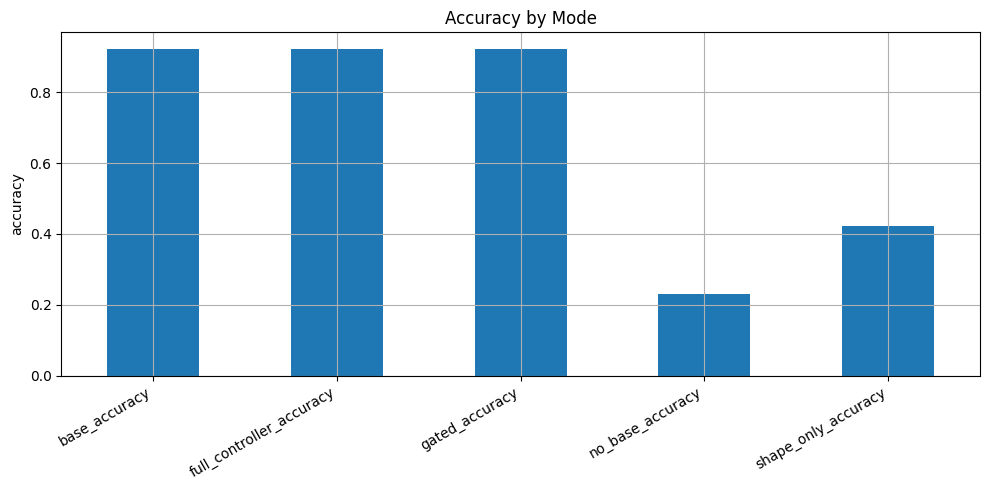

<Figure size 1000x500 with 0 Axes>

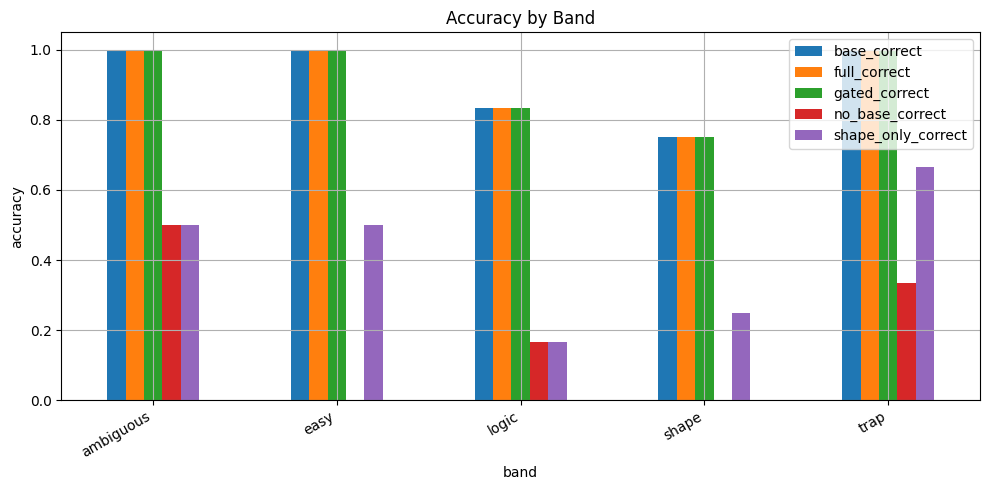

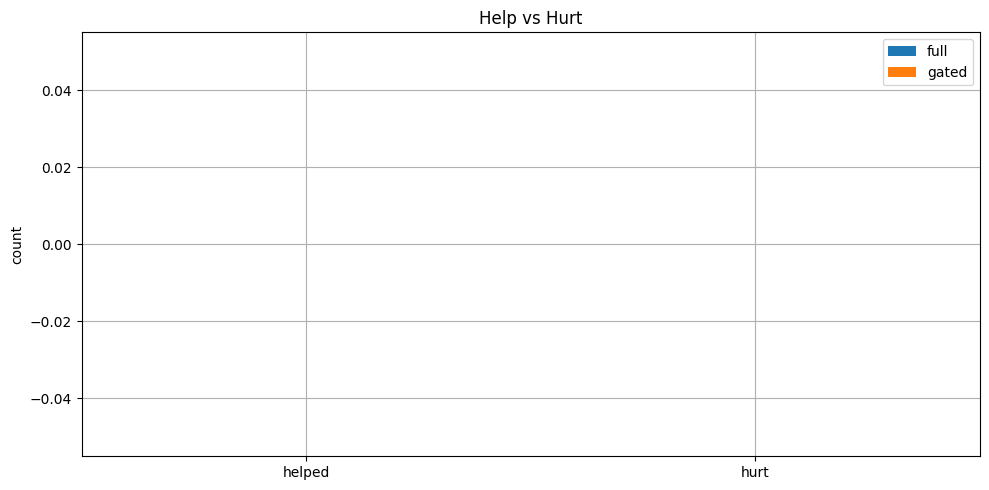

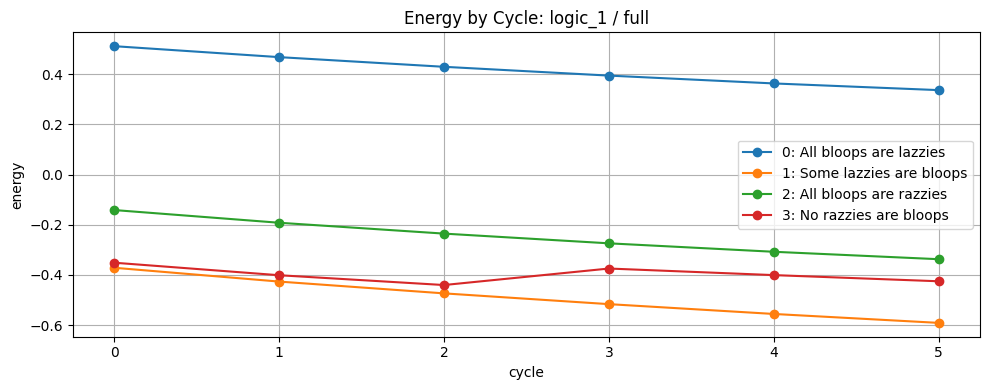

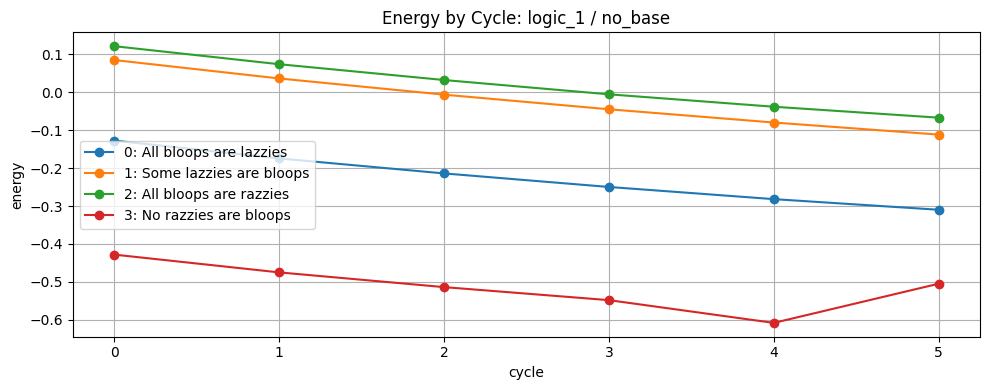

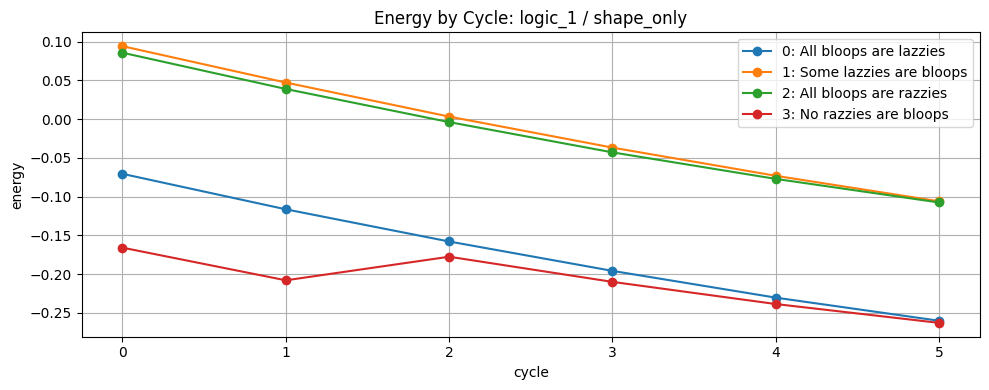

In [8]:
# Visual diagnostics
plt.figure(figsize=(9,4))
compare_summary[["base_accuracy","full_controller_accuracy","gated_accuracy","no_base_accuracy","shape_only_accuracy"]].T.plot(kind="bar", legend=False)
plt.title("Accuracy by Mode")
plt.ylabel("accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
by_band_compare.set_index("band")[["base_correct","full_correct","gated_correct","no_base_correct","shape_only_correct"]].plot(kind="bar")
plt.title("Accuracy by Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "full":[results_df["full_helped"].sum(), results_df["full_hurt"].sum()],
    "gated":[results_df["gated_helped"].sum(), results_df["gated_hurt"].sum()],
}, index=["helped","hurt"]).plot(kind="bar")
plt.title("Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_id = interesting["id"].iloc[0] if len(interesting) else results_df["id"].iloc[0]
for variant in VARIANTS:
    df=traces[(plot_id,variant)]
    plt.figure(figsize=(10,4))
    for ci in sorted(df["choice_idx"].unique()):
        d=df[df["choice_idx"]==ci]
        plt.plot(d["cycle"], d["energy"], marker="o", label=f"{ci}: {d['choice'].iloc[0]}")
    plt.title(f"Energy by Cycle: {plot_id} / {variant}")
    plt.xlabel("cycle")
    plt.ylabel("energy")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation

### LOCK

A meaningful improvement requires:

$$
\text{base wrong} \land \text{controller correct}
$$

or:

$$
\text{gated accuracy} > \text{base accuracy}
$$

on enough samples to matter.

### NON-LOCK

If base accuracy is already perfect:

$$
\Delta = 0
$$

That is not failure. It means no resistance.

### Ω

If `full` improves but `no_base` and `shape_only` collapse:

$$
\Omega: \text{controller may only be reweighting base logits}
$$

If `no_base` performs above chance on hard/trap bands:

$$
\Psi: \text{shape signal exists independently}
$$

If gating prevents hurt while preserving help:

$$
\Psi: \text{controller is usable as repair layer}
$$